# SARIMAX — Groundwater Level Forecasting


## 1. Imports & Configuration

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Vis settings

In [ ]:
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_palette('tab10')


Variable settings

In [ ]:
TARGET          = 'water_level'
EXOG_COLS       = ['temperature', 'precipitation', 'wind_speed']
SEASONAL_PERIOD = 12

print('Setup complete.')

Setup complete.


## 2. Data Loading

Loading data function

In [ ]:
def load_and_prepare(path):
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').asfreq('MS')
    return df

In [ ]:
train = load_and_prepare('uk_train.csv')
valid = load_and_prepare('uk_validate.csv')
test  = load_and_prepare('uk_test.csv')

# print data information

print(f'Train : {train.index.min().date().strftime("%Y,%m")} → {train.index.max().date().strftime("%Y,%m")}  ({len(train)} months)')
print(f'Valid : {valid.index.min().date().strftime("%Y,%m")} → {valid.index.max().date().strftime("%Y,%m")}  ({len(valid)} months)')
print(f'Test  : {test.index.min().date().strftime("%Y,%m")}  → {test.index.max().date().strftime("%Y,%m")}   ({len(test)} months)')

Train : 1944,01 → 2007,10  (766 months)
Valid : 2007,11 → 2015,10  (96 months)
Test  : 2015,11  → 2023,10   (96 months)


Splitting function to split the data to y and x

In [ ]:
def clean_split(df, target=TARGET, exog_cols=EXOG_COLS):
  mask = df[target].notna() & df[exog_cols].notna().all(axis=1) # confrim no nan in both the target and the exog
  return df.loc[mask, target], df.loc[mask, exog_cols]

In [ ]:
y_train, X_train = clean_split(train)
y_valid, X_valid = clean_split(valid)
y_test,  X_test  = clean_split(test)

# print to confirm the split is correct
print(f'y_train: {y_train.shape} | y_valid: {y_valid.shape} | y_test: {y_test.shape}')
print(f'X_train: {X_train.shape} | X_valid: {X_valid.shape} | X_test: {X_test.shape}')
print(f'\nFrequency: {y_train.index.freq}')

y_train: (766,) | y_valid: (96,) | y_test: (96,)
X_train: (766, 3) | X_valid: (96, 3) | X_test: (96, 3)

Frequency: <MonthBegin>


## 3. EDA & Stationarity Tests

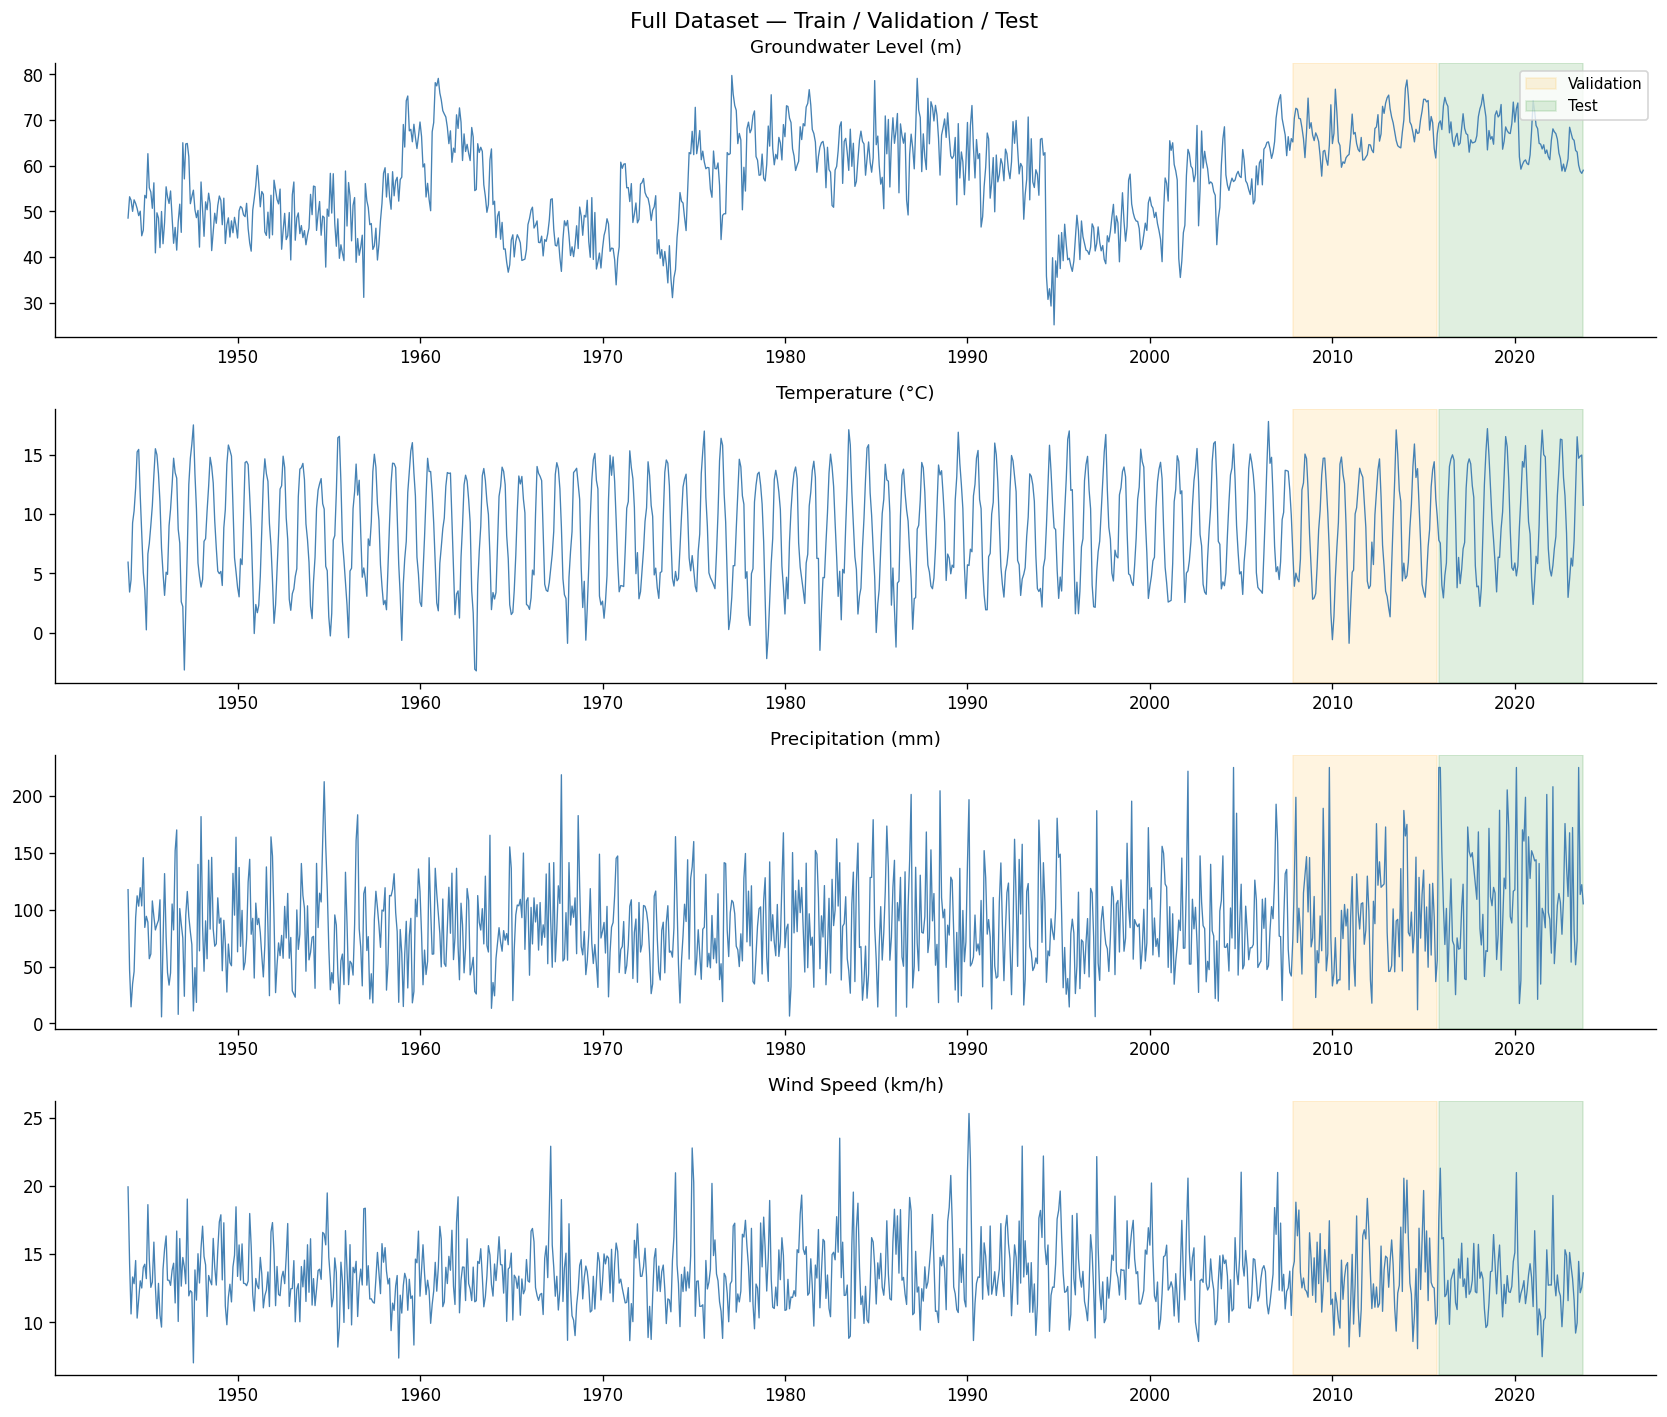

In [ ]:
# ── Time series overview ──────────────────────────────────────────────────────
full = pd.concat([train, valid, test])
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)

for ax, col, title in zip(axes,
    [TARGET] + EXOG_COLS,
    ['Groundwater Level (m)', 'Temperature (°C)', 'Precipitation (mm)', 'Wind Speed (km/h)']):
    ax.plot(full.index, full[col], lw=0.8, color='steelblue')
    ax.axvspan(valid.index[0], valid.index[-1], alpha=0.12, color='orange', label='Validation')
    ax.axvspan(test.index[0],  test.index[-1],  alpha=0.12, color='green',  label='Test')
    ax.set_title(title, fontsize=11)
    ax.xaxis.set_major_locator(mdates.YearLocator(10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[0].legend(loc='upper right', fontsize=9)
plt.suptitle('Full Dataset — Train / Validation / Test', fontsize=13)
plt.tight_layout()
plt.savefig('fig1_overview.png', bbox_inches='tight')
plt.show()

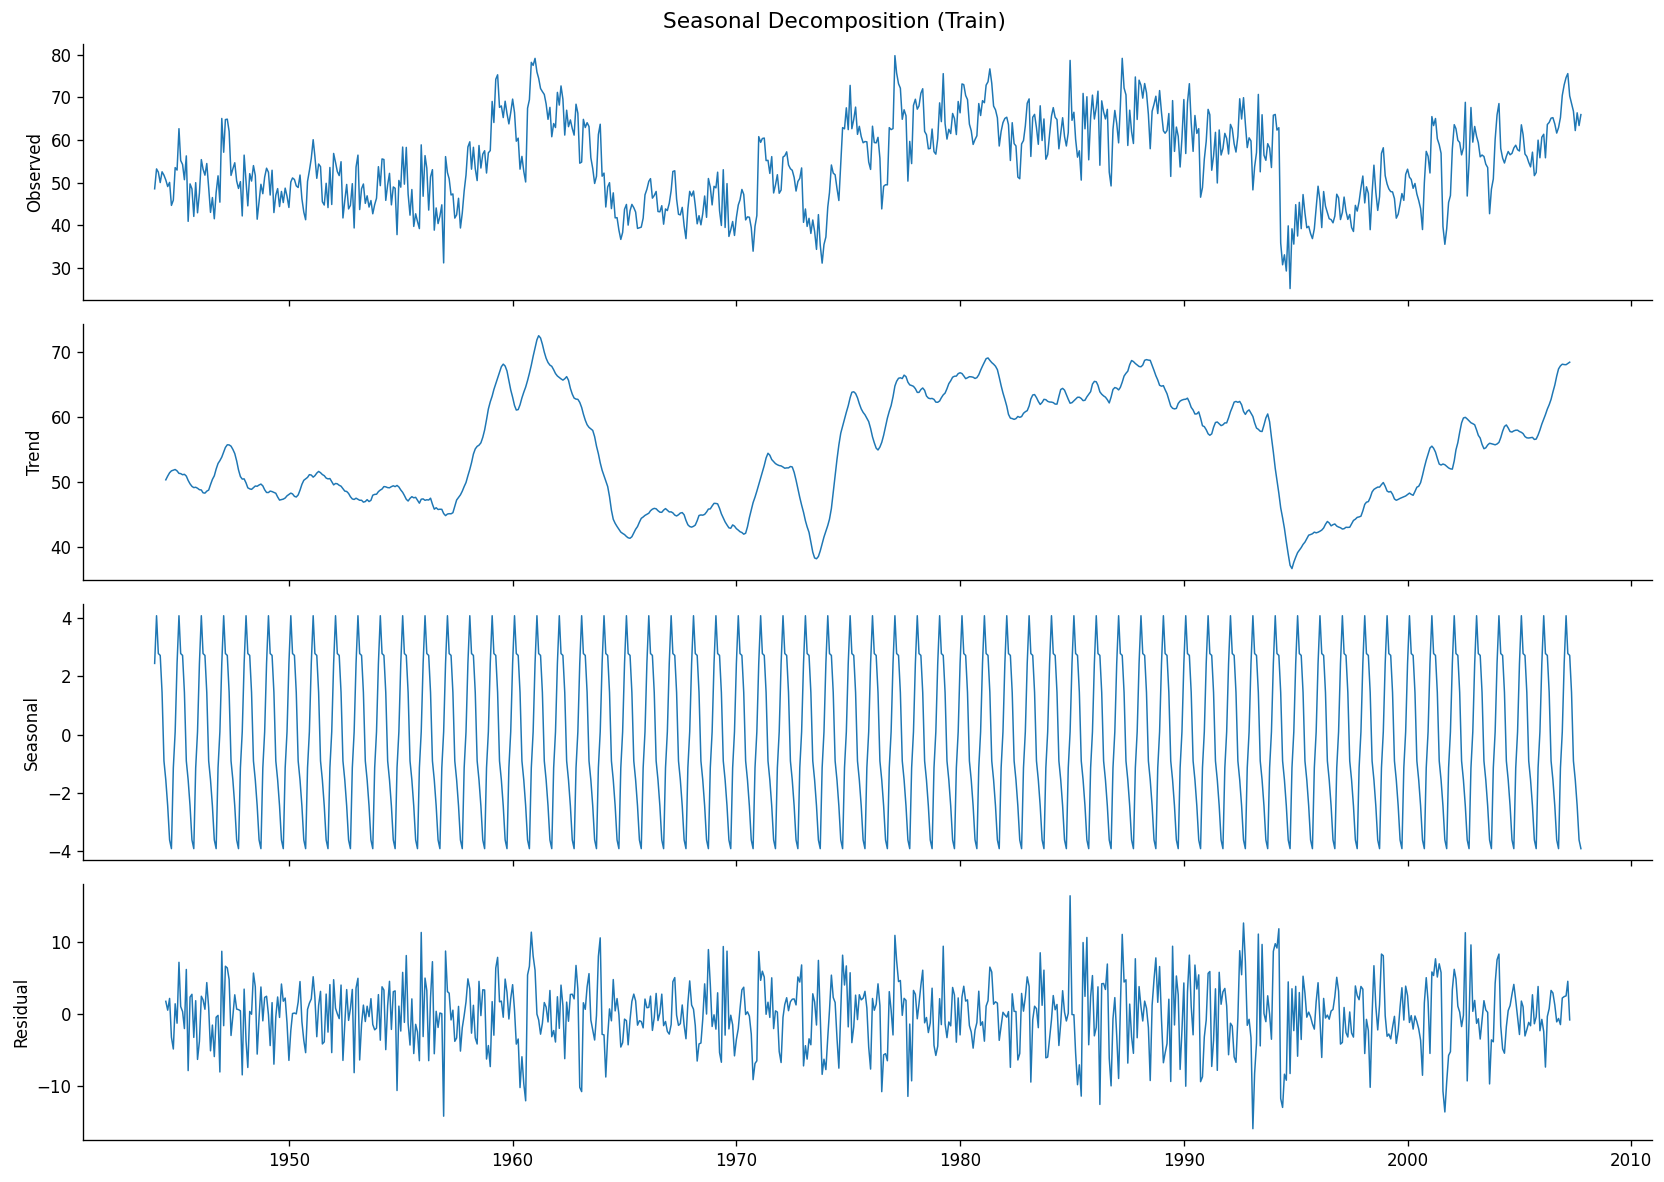

In [ ]:
# ── Seasonal decomposition ────────────────────────────────────────────────────
decomp = seasonal_decompose(y_train, model='additive', period=SEASONAL_PERIOD)
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, data, label in zip(axes,
    [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid],
    ['Observed', 'Trend', 'Seasonal', 'Residual']):
    ax.plot(data, lw=0.9)
    ax.set_ylabel(label)
plt.suptitle('Seasonal Decomposition (Train)', fontsize=13)
plt.tight_layout()
plt.savefig('fig2_decomposition.png', bbox_inches='tight')
plt.show()

Stationarity function

In [ ]:
for col in [TARGET] + EXOG_COLS:
    result = adfuller(train[col].dropna(), autolag='AIC')
    p  = kpss(train[col].dropna(), regression='c', nlags='auto')
    print(f'--- {col} ---')
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')
    print('ADF: Stationary' if result[1] <= 0.05 else 'ADF: Non-stationary')
    print(f'KPSS Statistic: {p[0]:.4f}')
    print(f'KPSS p-value: {p[1]:.4f}')
    print('KPSS: Stationary' if p[1] > 0.05 else 'KPSS: Non-stationary')
    print()

--- water_level ---
ADF Statistic : -3.0813
p-value       : 0.0280
ADF: Stationary
KPSS Statistic: 0.5118
KPSS p-value: 0.0390
KPSS: Non-stationary

--- temperature ---
ADF Statistic : -4.8380
p-value       : 0.0000
ADF: Stationary
KPSS Statistic: 0.2370
KPSS p-value: 0.1000
KPSS: Stationary

--- precipitation ---
ADF Statistic : -13.4903
p-value       : 0.0000
ADF: Stationary
KPSS Statistic: 0.2677
KPSS p-value: 0.1000
KPSS: Stationary

--- wind_speed ---
ADF Statistic : -6.9785
p-value       : 0.0000
ADF: Stationary
KPSS Statistic: 0.3222
KPSS p-value: 0.1000
KPSS: Stationary



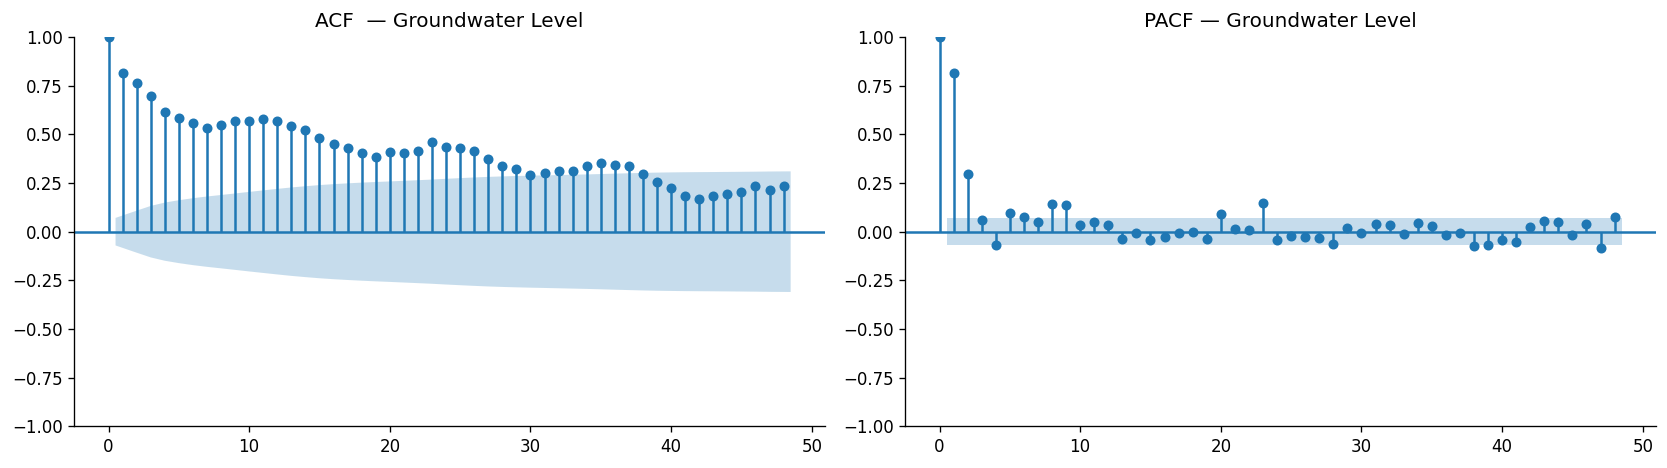

In [ ]:
# ── ACF / PACF — train only ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf (y_train, lags=48, ax=axes[0], title='ACF  — Groundwater Level')
plot_pacf(y_train, lags=48, ax=axes[1], title='PACF — Groundwater Level')
plt.tight_layout()
plt.savefig('fig3_acf_pacf.png', bbox_inches='tight')
plt.show()

# Bseline model

In [ ]:
# ── Baseline SARIMAX configuration ────────────────────────────────────────────
BASELINE_ORDER          = (1, 0, 1)
BASELINE_SEASONAL_ORDER = (1, 0, 1, SEASONAL_PERIOD)

print(f'Baseline configuration: SARIMAX{BASELINE_ORDER}x{BASELINE_SEASONAL_ORDER}')
print(f'Fitting on training set ({len(y_train)} observations)...')

baseline_res = SARIMAX(
    endog=y_train,
    exog=X_train,
    order=BASELINE_ORDER,
    seasonal_order=BASELINE_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=500)

print(f'\nModel fitted successfully.')
print(f'AIC: {baseline_res.aic:.2f}')
print(f'BIC: {baseline_res.bic:.2f}')
print(f'Number of parameters: {baseline_res.df_model}')

Baseline configuration: SARIMAX(1, 0, 1)x(1, 0, 1, 12)
Fitting on training set (766 observations)...

Model fitted successfully.
AIC: 4699.09
BIC: 4736.07
Number of parameters: 8


In [ ]:
# ── Baseline validation forecast ──────────────────────────────────────────────
baseline_fc     = baseline_res.get_forecast(steps=len(y_valid), exog=X_valid)
baseline_pred   = baseline_fc.predicted_mean

baseline_aligned = pd.concat(
    [y_valid.rename('actual'), baseline_pred.rename('pred')], axis=1
).dropna()

baseline_val_rmse = np.sqrt(mean_squared_error(baseline_aligned['actual'], baseline_aligned['pred']))
baseline_val_mae  = mean_absolute_error(baseline_aligned['actual'], baseline_aligned['pred'])
baseline_val_r2   = r2_score(baseline_aligned['actual'], baseline_aligned['pred'])

print('=== BASELINE VALIDATION METRICS ===')
print(f'Model          : SARIMAX{BASELINE_ORDER}x{BASELINE_SEASONAL_ORDER}')
print(f'Val RMSE       : {baseline_val_rmse:.4f}')
print(f'Val MAE        : {baseline_val_mae:.4f}')
print(f'Val R²         : {baseline_val_r2:.4f}')
print(f'AIC            : {baseline_res.aic:.2f}')
print(f'BIC            : {baseline_res.bic:.2f}')

=== BASELINE VALIDATION METRICS ===
Model          : SARIMAX(1, 0, 1)x(1, 0, 1, 12)
Val RMSE       : 10.6065
Val MAE        : 9.2072
Val R²         : -4.4895
AIC            : 4699.09
BIC            : 4736.07


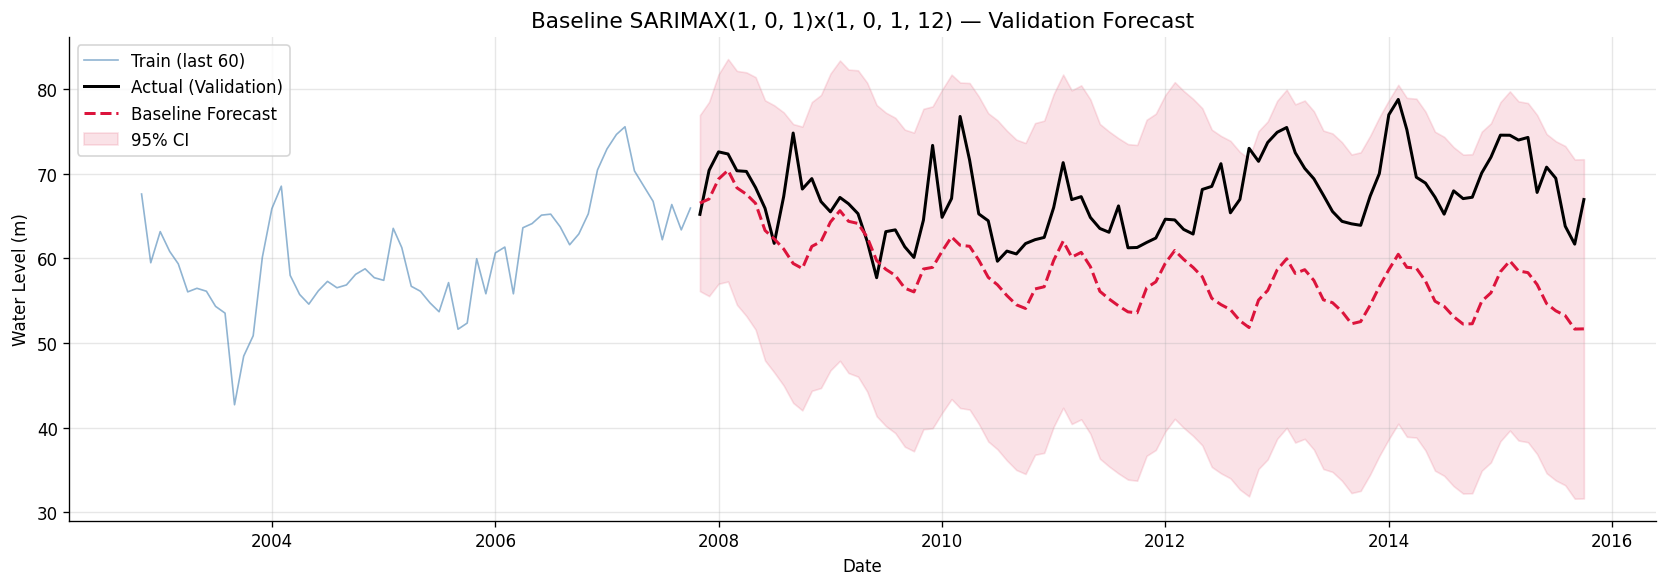


Baseline val RMSE: 10.6065 — this is the performance floor to improve upon.


In [ ]:
# ── Baseline forecast plot ────────────────────────────────────────────────────
baseline_ci = baseline_fc.conf_int()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y_train.index[-60:], y_train.iloc[-60:],
        color='steelblue', lw=1, alpha=0.6, label='Train (last 60)')
ax.plot(baseline_aligned.index, baseline_aligned['actual'],
        color='black', lw=1.8, label='Actual (Validation)')
ax.plot(baseline_aligned.index, baseline_aligned['pred'],
        color='crimson', lw=1.8, linestyle='--', label='Baseline Forecast')
ax.fill_between(
    baseline_ci.index, baseline_ci.iloc[:, 0], baseline_ci.iloc[:, 1],
    color='crimson', alpha=0.12, label='95% CI'
)

ax.set_title(f'Baseline SARIMAX{BASELINE_ORDER}x{BASELINE_SEASONAL_ORDER} — Validation Forecast', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Water Level (m)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_baseline_validation.png', bbox_inches='tight')
plt.show()

print(f'\nBaseline val RMSE: {baseline_val_rmse:.4f} — this is the performance floor to improve upon.')

In [ ]:
# ── Refit baseline on train+validation, evaluate on test ──────────────────────
trainval = pd.concat([train, valid]).sort_index()
y_trainval, X_trainval = clean_split(trainval)

baseline_final = SARIMAX(
    endog=y_trainval,
    exog=X_trainval,
    order=BASELINE_ORDER,
    seasonal_order=BASELINE_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=500)

# Forecast on test set
baseline_test_fc   = baseline_final.get_forecast(steps=len(y_test), exog=X_test)
baseline_test_pred = baseline_test_fc.predicted_mean

baseline_test_aligned = pd.concat(
    [y_test.rename('actual'), baseline_test_pred.rename('pred')], axis=1
).dropna()

baseline_test_rmse = np.sqrt(mean_squared_error(baseline_test_aligned['actual'], baseline_test_aligned['pred']))
baseline_test_mae  = mean_absolute_error(baseline_test_aligned['actual'], baseline_test_aligned['pred'])
baseline_test_r2   = r2_score(baseline_test_aligned['actual'], baseline_test_aligned['pred'])
baseline_test_nse  = 1 - np.sum((baseline_test_aligned['actual'] - baseline_test_aligned['pred'])**2) /                          np.sum((baseline_test_aligned['actual'] - baseline_test_aligned['actual'].mean())**2)

print('=== BASELINE TEST SET METRICS ===')
print(f'Model     : SARIMAX{BASELINE_ORDER}x{BASELINE_SEASONAL_ORDER}')
print(f'Test RMSE : {baseline_test_rmse:.4f}')
print(f'Test MAE  : {baseline_test_mae:.4f}')
print(f'Test R²   : {baseline_test_r2:.4f}')
print(f'Test NSE  : {baseline_test_nse:.4f}')

=== BASELINE TEST SET METRICS ===
Model     : SARIMAX(1, 0, 1)x(1, 0, 1, 12)
Test RMSE : 5.6949
Test MAE  : 4.8761
Test R²   : -0.6881
Test NSE  : -0.6881


## 4. Grid Search (changed it to Bayesian hyperparameter optmiser)




In [ ]:
# # set ranges of parameters
# p_range = range(0, 3)
# d_range = range(0, 2)
# q_range = range(0, 3)
# P_range = range(0, 3)
# D_range = range(0, 2)
# Q_range = range(0, 3)
# s = SEASONAL_PERIOD

# pdq          = list(itertools.product(p_range, d_range, q_range))
# seasonal_pdq = [(P, D, Q, s) for P, D, Q in itertools.product(P_range, D_range, Q_range)]

# combos = [
#     (order, seasonal_order)
#     for order, seasonal_order in itertools.product(pdq, seasonal_pdq)
# ]

# print(f'Total combinations : {len(combos)}')

In [ ]:
# records = []
# total   = len(combos)

# # iterate through the diffrent combenatitons of orders
# for i, (order, seasonal_order) in enumerate(combos, 1):
#     try:
#       # creat a sarimax model and fit it
#         res = SARIMAX(
#             endog          = y_train,
#             exog           = X_train,
#             order          = order,
#             seasonal_order = seasonal_order,
#             enforce_stationarity  = False,
#             enforce_invertibility = False,
#         ).fit(disp=False, maxiter=500)

#         # predict the validation set
#         fc      = res.get_forecast(steps=len(y_valid), exog=X_valid)
#         y_pred  = fc.predicted_mean

#         aligned = pd.concat(
#             [y_valid.rename('actual'), y_pred.rename('pred')], axis=1
#         ).dropna()

#         #Calculate the rmse and mae of the predictions compared to the atual values
#         val_rmse = np.sqrt(mean_squared_error(aligned['actual'], aligned['pred']))
#         val_mae  = mean_absolute_error(aligned['actual'], aligned['pred'])

# # save the results to the record as a dictionary
#         records.append({
#             'order'         : order,
#             'seasonal_order': seasonal_order,
#             'AIC'           : res.aic,
#             'BIC'           : res.bic,
#             'val_RMSE'      : val_rmse,
#             'val_MAE'       : val_mae,
#         })

# # print the round results
#         print(f'[{i:>4}/{total}]  SARIMA{order}x{seasonal_order}  '
#               f'AIC={res.aic:8.2f}  val_RMSE={val_rmse:.4f}')

#     except Exception as e:
#         print(f'[{i:>4}/{total}]  SARIMA{order}x{seasonal_order}  FAILED: {e}')

# grid_results = (
#     pd.DataFrame(records)
#     .sort_values('val_RMSE')
#     .reset_index(drop=True)
# )
# # the values sorted according to RMSE


# grid_results.to_csv('table2_grid_results.csv', index=False) # save the records to a csv file

# print('\n=== TOP 10 MODELS BY VALIDATION RMSE ===')
# print(grid_results.head(10).to_string())

# best = {
#     'order'         : grid_results.loc[0, 'order'],
#     'seasonal_order': grid_results.loc[0, 'seasonal_order'],
# }
# print(f"\nBest order          : {best['order']}")
# print(f"Best seasonal_order : {best['seasonal_order']}")
# print(f"Best val_RMSE       : {grid_results.loc[0, 'val_RMSE']:.4f}")

## Bayesian Hyperparameter Optimisation

In [ ]:
!pip install optuna -q
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('Optuna version:', optuna.__version__)

Optuna version: 4.8.0


In [ ]:

def sarimax_objective(trial):
    # hyperparameters range
    p = trial.suggest_int("p", 0, 2)
    d = trial.suggest_int("d", 0, 1)
    q = trial.suggest_int("q", 0, 2)

    P = trial.suggest_int("P", 0, 2)
    D = trial.suggest_int("D", 0, 1)
    Q = trial.suggest_int("Q", 0, 2)

    order = (p, d, q)
    seasonal_order = (P, D, Q, SEASONAL_PERIOD)

    try:
        model = SARIMAX(
            endog=y_train,
            exog=X_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        )

        res = model.fit(disp=False, maxiter=500)

        fc = res.get_forecast(steps=len(y_valid), exog=X_valid)
        y_pred = fc.predicted_mean

        aligned = pd.concat(
            [y_valid.rename("actual"), y_pred.rename("pred")], axis=1
        ).dropna()

        if len(aligned) == 0:
            return float("inf")

        val_rmse = np.sqrt(mean_squared_error(aligned["actual"], aligned["pred"]))
        val_mae = mean_absolute_error(aligned["actual"], aligned["pred"])

        # Save extra trial info
        trial.set_user_attr("order", order)
        trial.set_user_attr("seasonal_order", seasonal_order)
        trial.set_user_attr("AIC", float(res.aic))
        trial.set_user_attr("BIC", float(res.bic))
        trial.set_user_attr("val_MAE", float(val_mae))

        return val_rmse

    except Exception as e:
        trial.set_user_attr("failed_reason", str(e))
        return float("inf")

In [ ]:
# Reproducible Bayesian search
from optuna.samplers import TPESampler
sampler = TPESampler(seed=42)

study = optuna.create_study(
    direction="minimize",
    sampler=sampler,
    study_name="sarimax_bayesian_optimization"
)

N_TRIALS = 50   # try 30–60 first, then increase if needed

study.optimize(sarimax_objective, n_trials=N_TRIALS, show_progress_bar=True)

In [ ]:
records = []

for trial in study.trials:
    records.append({
        "trial_number": trial.number,
        "order": trial.user_attrs.get("order"),
        "seasonal_order": trial.user_attrs.get("seasonal_order"),
        "AIC": trial.user_attrs.get("AIC"),
        "BIC": trial.user_attrs.get("BIC"),
        "val_RMSE": trial.value,
        "val_MAE": trial.user_attrs.get("val_MAE"),
        "status": trial.state.name,
        "failed_reason": trial.user_attrs.get("failed_reason", None)
    })

bayes_results = (
    pd.DataFrame(records)
    .sort_values("val_RMSE", ascending=True)
    .reset_index(drop=True)
)

bayes_results.to_csv("table2_bayes_results.csv", index=False)

print("\n=== TOP 10 MODELS BY VALIDATION RMSE ===")
print(bayes_results.head(10).to_string())


=== TOP 10 MODELS BY VALIDATION RMSE ===
   trial_number      order seasonal_order          AIC          BIC  val_RMSE   val_MAE    status failed_reason
0            14  (2, 1, 1)  (2, 0, 2, 12)  4623.946147  4674.604424  3.972272  3.323066  COMPLETE          None
1            46  (2, 1, 1)  (2, 0, 2, 12)  4623.946147  4674.604424  3.972272  3.323066  COMPLETE          None
2            31  (2, 1, 1)  (1, 0, 1, 12)  4693.570172  4735.162823  3.977454  3.327118  COMPLETE          None
3            15  (2, 1, 1)  (1, 0, 1, 12)  4693.570172  4735.162823  3.977454  3.327118  COMPLETE          None
4            21  (2, 1, 1)  (1, 0, 1, 12)  4693.570172  4735.162823  3.977454  3.327118  COMPLETE          None
5            22  (2, 1, 1)  (1, 0, 1, 12)  4693.570172  4735.162823  3.977454  3.327118  COMPLETE          None
6            19  (2, 1, 1)  (1, 0, 1, 12)  4693.570172  4735.162823  3.977454  3.327118  COMPLETE          None
7            23  (2, 1, 1)  (1, 0, 1, 12)  4693.570172  4735.1

In [ ]:
best_trial = study.best_trial

best = {
    "order": best_trial.user_attrs["order"],
    "seasonal_order": best_trial.user_attrs["seasonal_order"],
    "val_RMSE": best_trial.value,
    "AIC": best_trial.user_attrs["AIC"],
    "BIC": best_trial.user_attrs["BIC"]
}

print("\n=== BEST BAYESIAN MODEL ===")
print(best)


=== BEST BAYESIAN MODEL ===
{'order': (2, 1, 1), 'seasonal_order': (2, 0, 2, 12), 'val_RMSE': 3.9722717007697574, 'AIC': 4623.946147237674, 'BIC': 4674.604424368104}


## 5. Final Model — Refit on Train + Validation

In [ ]:

trainval          = pd.concat([train, valid]).sort_index()
y_trainval, X_trainval = clean_split(trainval)

# Confirm no leakage into test
assert y_trainval.index.max() < y_test.index.min(), 'LEAKAGE: trainval bleeds into test'

final_res = SARIMAX(
    endog          = y_trainval,
    exog           = X_trainval,
    order          = best['order'],
    seasonal_order = best['seasonal_order'],
    enforce_stationarity  = False,
    enforce_invertibility = False,
).fit(disp=False, maxiter=500)

print(final_res.summary())

                                        SARIMAX Results                                        
Dep. Variable:                             water_level   No. Observations:                  862
Model:             SARIMAX(2, 1, 1)x(2, 0, [1, 2], 12)   Log Likelihood               -2565.846
Date:                                 Mon, 06 Apr 2026   AIC                           5153.691
Time:                                         18:14:51   BIC                           5205.693
Sample:                                     01-01-1944   HQIC                          5173.627
                                          - 10-01-2015                                         
Covariance Type:                                   opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
temperature       0.1270      0.132      0.965      0.334      -0.13

## 6. Forecast on Test Set



In [ ]:
fc_test     = final_res.get_forecast(steps=len(y_test), exog=X_test)
y_test_pred = fc_test.predicted_mean
ci_test     = fc_test.conf_int()

eval_df = pd.DataFrame({
    'Actual'   : y_test,
    'Predicted': y_test_pred,
}, index=y_test.index).dropna()
eval_df['Error']     = eval_df['Actual'] - eval_df['Predicted']
eval_df['Abs_Error'] = eval_df['Error'].abs()

print(f'Forecast rows: {len(eval_df)}')

Forecast rows: 96


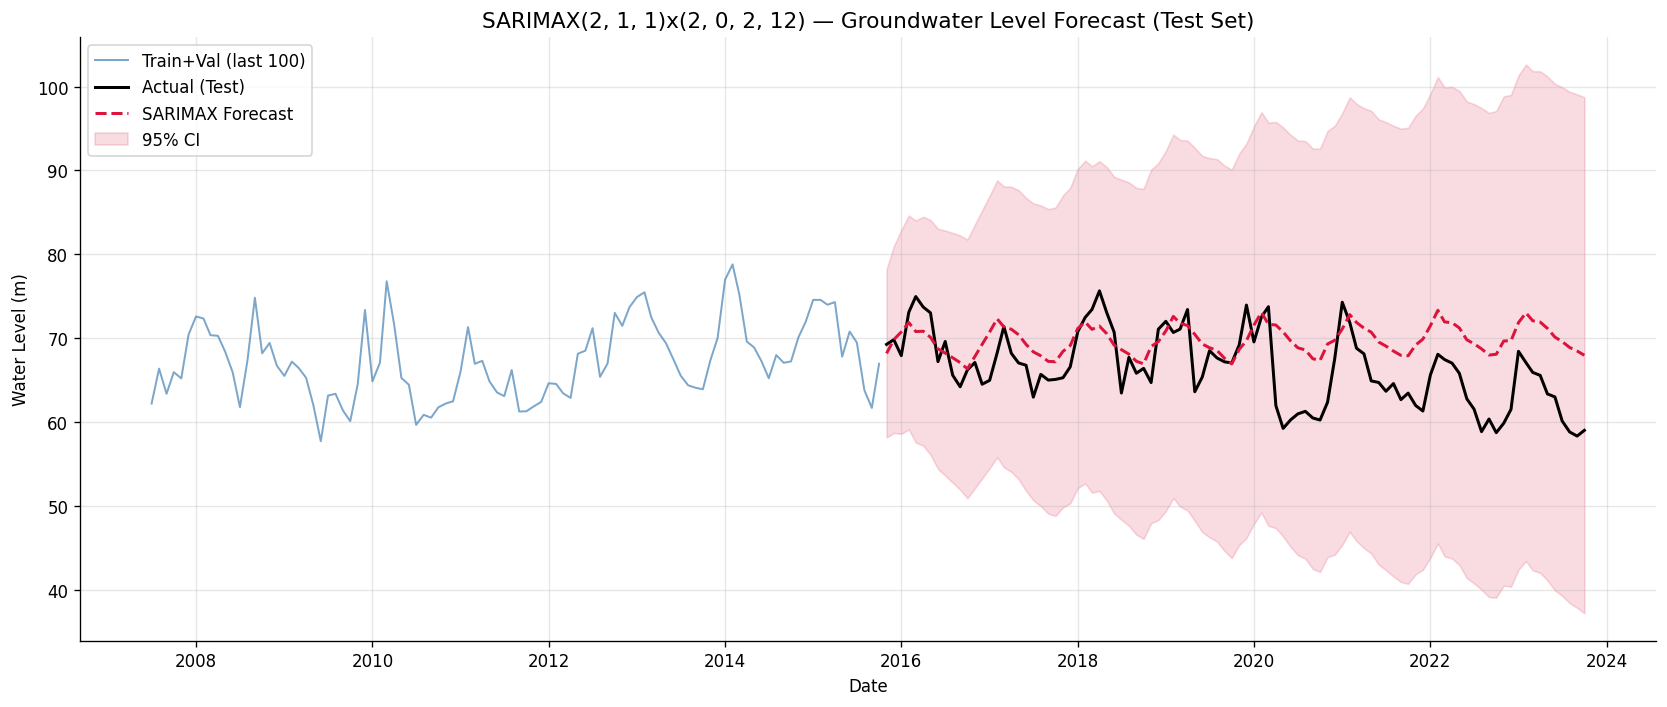

In [ ]:
# ── Forecast plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_trainval.index[-100:], y_trainval.iloc[-100:],
        color='steelblue', lw=1.2, alpha=0.7, label='Train+Val (last 100)')
ax.plot(eval_df.index, eval_df['Actual'],
        color='black', lw=1.8, label='Actual (Test)')
ax.plot(eval_df.index, eval_df['Predicted'],
        color='crimson', lw=1.8, linestyle='--', label='SARIMAX Forecast')
ax.fill_between(
    ci_test.index, ci_test.iloc[:, 0], ci_test.iloc[:, 1],
    color='crimson', alpha=0.15, label='95% CI'
)

ax.set_title(f'SARIMAX(2, 1, 1)x(2, 0, 2, 12) — Groundwater Level Forecast (Test Set)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Water Level (m)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig4_forecast.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Baseline vs Tuned — Validation Comparison ─────────────────────────────────
tuned_val_rmse = bayes_results.loc[0, 'val_RMSE']
tuned_val_mae  = bayes_results.loc[0, 'val_MAE']
tuned_val_aic  = bayes_results.loc[0, 'AIC']

comparison_val = pd.DataFrame({
    'Metric': ['Val RMSE', 'Val MAE', 'AIC'],
    'Baseline': [
        round(baseline_val_rmse, 4),
        round(baseline_val_mae, 4),
        round(baseline_res.aic, 2),
    ],
    'Tuned (Bayesian)': [
        round(tuned_val_rmse, 4),
        round(tuned_val_mae, 4),
        round(tuned_val_aic, 2),
    ],
})

comparison_val['Improvement'] = comparison_val.apply(
    lambda row: f"{((row['Baseline'] - row['Tuned (Bayesian)']) / row['Baseline'] * 100):+.1f}%", axis=1
)

print('=== BASELINE vs TUNED — VALIDATION SET ===')
print(f'Baseline : SARIMAX(1, 0, 1)x(1, 0, 1, 12)')
print(f'Tuned    : SARIMAX(2, 1, 1)x(2, 0, 2, 12)')
print()
print(comparison_val.to_string(index=False))

rmse_improvement = (baseline_val_rmse - tuned_val_rmse) / baseline_val_rmse * 100
print(f'\nBayesian optimisation reduced validation RMSE by {rmse_improvement:.1f}% relative to the baseline.')

=== BASELINE vs TUNED — VALIDATION SET ===
Baseline : SARIMAX(1, 0, 1)x(1, 0, 1, 12)
Tuned    : SARIMAX(2, 1, 1)x(2, 0, 2, 12)

  Metric  Baseline  Tuned (Bayesian) Improvement
Val RMSE   10.6065            3.9723      +62.5%
 Val MAE    9.2072            3.3231      +63.9%
     AIC 4699.0900         4623.9500       +1.6%

Bayesian optimisation reduced validation RMSE by 62.5% relative to the baseline.


BASELINE vs TUNED — TEST SET COMPARISON
Baseline : SARIMAX(1, 0, 1)x(1, 0, 1, 12)
Tuned    : SARIMAX(2, 1, 1)x(2, 0, 2, 12)

Metric  Baseline  Tuned (Bayesian) Change
  RMSE    5.6949            5.1540  +9.5%
   MAE    4.8761            4.1969 +13.9%
    R²   -0.6881           -0.3826 +44.4%
   NSE   -0.6881           -0.3826 +44.4%



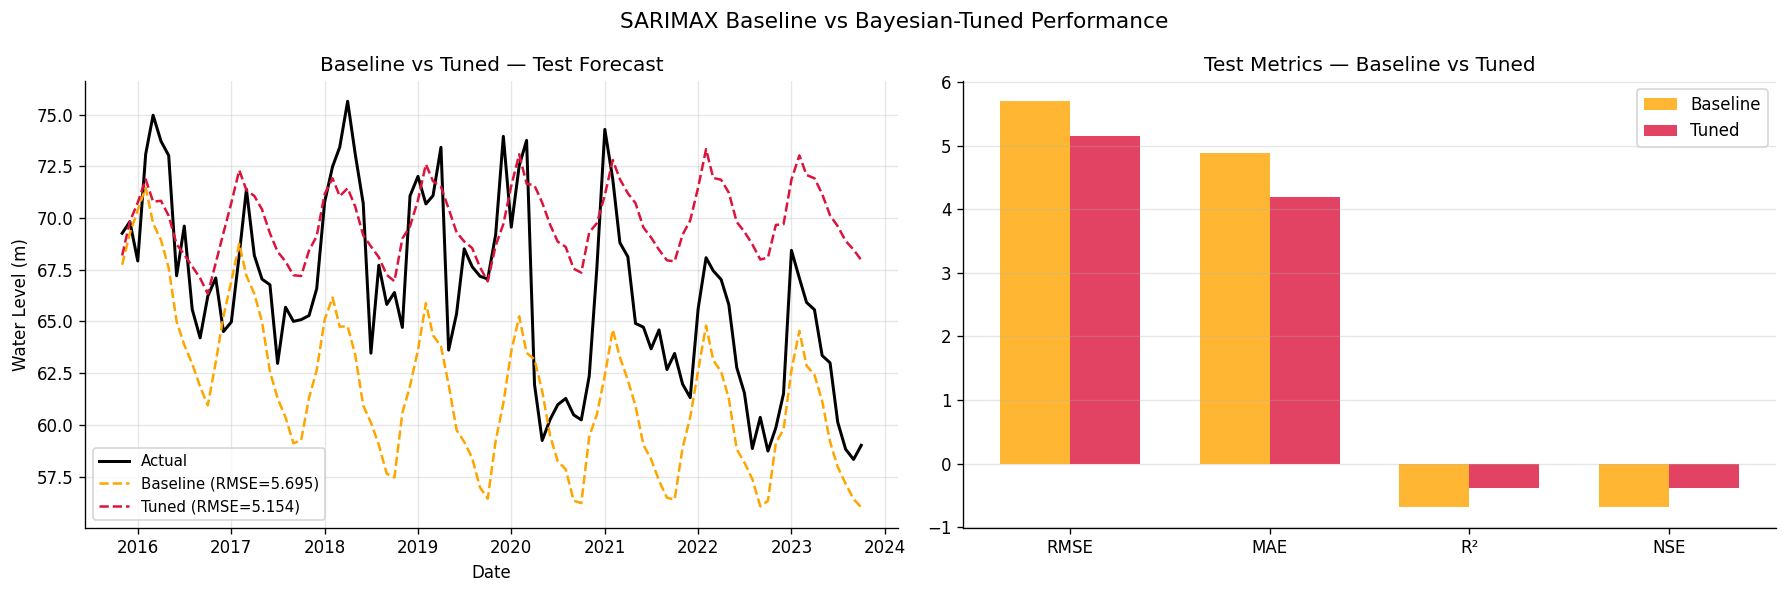

In [ ]:
# ── Final comparison — Test Set ───────────────────────────────────────────────
y_true = eval_df['Actual']
y_pred = eval_df['Predicted']

tuned_test_rmse = float(global_metrics['RMSE'])
tuned_test_mae  = float(global_metrics['MAE'])
tuned_test_r2   = float(global_metrics['R²'])
tuned_test_nse  = float(global_metrics['NSE'])

comparison_test = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'R²', 'NSE'],
    'Baseline': [
        round(baseline_test_rmse, 4),
        round(baseline_test_mae, 4),
        round(baseline_test_r2, 4),
        round(baseline_test_nse, 4),
    ],
    'Tuned (Bayesian)': [
        round(tuned_test_rmse, 4),
        round(tuned_test_mae, 4),
        round(tuned_test_r2, 4),
        round(tuned_test_nse, 4),
    ],
})

# For RMSE/MAE lower is better; for R²/NSE higher is better
def calc_improvement(row):
    if row['Metric'] in ['RMSE', 'MAE']:
        return f"{((row['Baseline'] - row['Tuned (Bayesian)']) / abs(row['Baseline']) * 100):+.1f}%"
    else:
        return f"{((row['Tuned (Bayesian)'] - row['Baseline']) / max(abs(row['Baseline']), 1e-8) * 100):+.1f}%"

comparison_test['Change'] = comparison_test.apply(calc_improvement, axis=1)

print('=' * 65)
print('BASELINE vs TUNED — TEST SET COMPARISON')
print('=' * 65)
print(f'Baseline : SARIMAX{BASELINE_ORDER}x{BASELINE_SEASONAL_ORDER}')
print(f'Tuned    : SARIMAX{best["order"]}x{best["seasonal_order"]}')
print()
print(comparison_test.to_string(index=False))
print()

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Forecast overlay
axes[0].plot(baseline_test_aligned.index, baseline_test_aligned['actual'],
             color='black', lw=1.8, label='Actual')
axes[0].plot(baseline_test_aligned.index, baseline_test_aligned['pred'],
             color='orange', lw=1.5, linestyle='--', label=f'Baseline (RMSE={baseline_test_rmse:.3f})')
axes[0].plot(eval_df.index, eval_df['Predicted'],
             color='crimson', lw=1.5, linestyle='--', label=f'Tuned (RMSE={tuned_test_rmse:.3f})')
axes[0].set_title('Baseline vs Tuned — Test Forecast')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Water Level (m)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# 2. Metric bar chart
metrics = ['RMSE', 'MAE', 'R²', 'NSE']
baseline_vals = [baseline_test_rmse, baseline_test_mae, baseline_test_r2, baseline_test_nse]
tuned_vals    = [tuned_test_rmse, tuned_test_mae, tuned_test_r2, tuned_test_nse]

x = np.arange(len(metrics))
w = 0.35
axes[1].bar(x - w/2, baseline_vals, w, label='Baseline', color='orange', alpha=0.8)
axes[1].bar(x + w/2, tuned_vals, w, label='Tuned', color='crimson', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].set_title('Test Metrics — Baseline vs Tuned')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('SARIMAX Baseline vs Bayesian-Tuned Performance', fontsize=13)
plt.tight_layout()
plt.savefig('fig_baseline_vs_tuned.png', bbox_inches='tight')
plt.show()

## 7. Evaluation Metrics

In [ ]:
def safe_mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom  = np.where(np.abs(y_true) < eps, np.nan, y_true)
    return np.nanmean(np.abs((y_true - y_pred) / denom)) * 100

y_true = eval_df['Actual']
y_pred = eval_df['Predicted']

# Global metrics
global_metrics = pd.Series({
    'RMSE'    : np.sqrt(mean_squared_error(y_true, y_pred)),
    'MAE'     : mean_absolute_error(y_true, y_pred),
    'MAPE (%)': safe_mape(y_true, y_pred),
    'R²'      : r2_score(y_true, y_pred),
    'NSE'     : 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2),
}).round(4)

print('=== GLOBAL TEST METRICS ===')
print(global_metrics.to_frame(name='SARIMAX').to_string())

# Peak performance (top 10% of actual values)
thresh   = y_true.quantile(0.90)
peak_df  = eval_df[eval_df['Actual'] >= thresh]
peak_metrics = pd.Series({
    'Threshold (90th pct)': round(thresh, 4),
    'N peak samples'      : len(peak_df),
    'Peak RMSE'           : round(np.sqrt(mean_squared_error(peak_df['Actual'], peak_df['Predicted'])), 4),
    'Peak MAE'            : round(mean_absolute_error(peak_df['Actual'], peak_df['Predicted']), 4),
    'Avg bias (Act-Pred)' : round(peak_df['Error'].mean(), 4),
})

print('\n=== PEAK PERFORMANCE (≥ 90th percentile) ===')
print(peak_metrics.to_string())

# Save benchmark table (add LSTM/TCN columns later)
global_metrics.to_frame(name='SARIMAX').to_csv('table3_benchmark_metrics.csv')
print('\nSaved → table3_benchmark_metrics.csv')

=== GLOBAL TEST METRICS ===
          SARIMAX
RMSE       5.1540
MAE        4.1969
MAPE (%)   6.5844
R²        -0.3826
NSE       -0.3826

=== PEAK PERFORMANCE (≥ 90th percentile) ===
Threshold (90th pct)    73.0418
N peak samples          10.0000
Peak RMSE                3.0496
Peak MAE                 2.8794
Avg bias (Act-Pred)      2.8794

Saved → table3_benchmark_metrics.csv


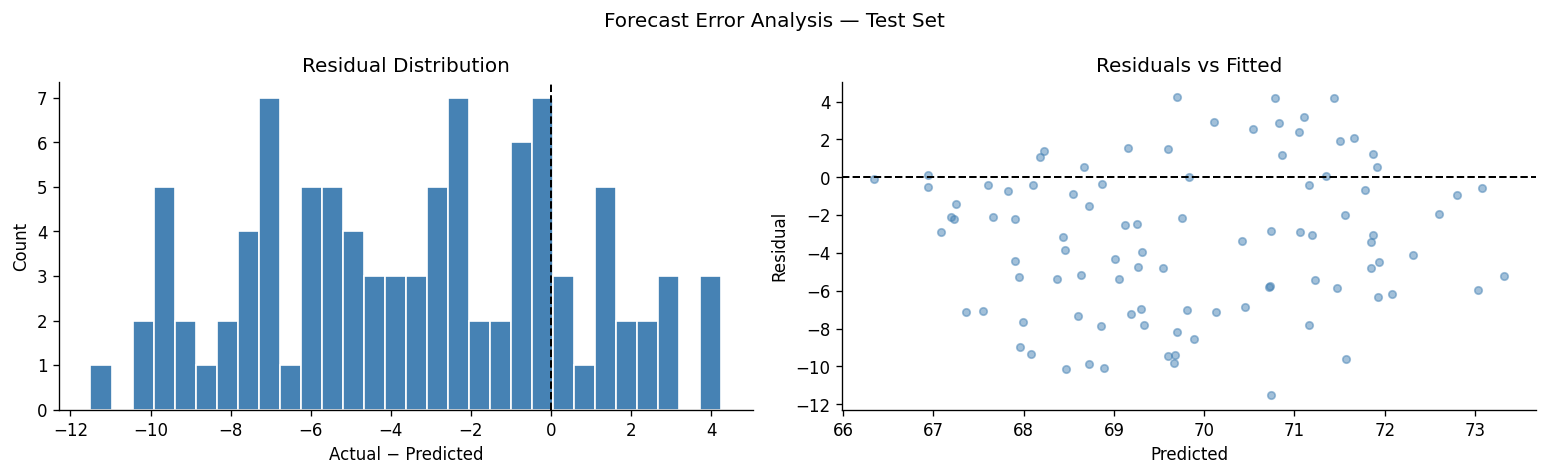

In [ ]:
# ── Error distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(eval_df['Error'], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='black', lw=1.2, linestyle='--')
axes[0].set_title('Residual Distribution')
axes[0].set_xlabel('Actual − Predicted')
axes[0].set_ylabel('Count')

axes[1].scatter(eval_df['Predicted'], eval_df['Error'], alpha=0.5, s=20, color='steelblue')
axes[1].axhline(0, color='black', lw=1.2, linestyle='--')
axes[1].set_title('Residuals vs Fitted')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')

plt.suptitle('Forecast Error Analysis — Test Set', fontsize=12)
plt.tight_layout()
plt.savefig('fig5_error_analysis.png', bbox_inches='tight')
plt.show()

## 8. Residual Diagnostics

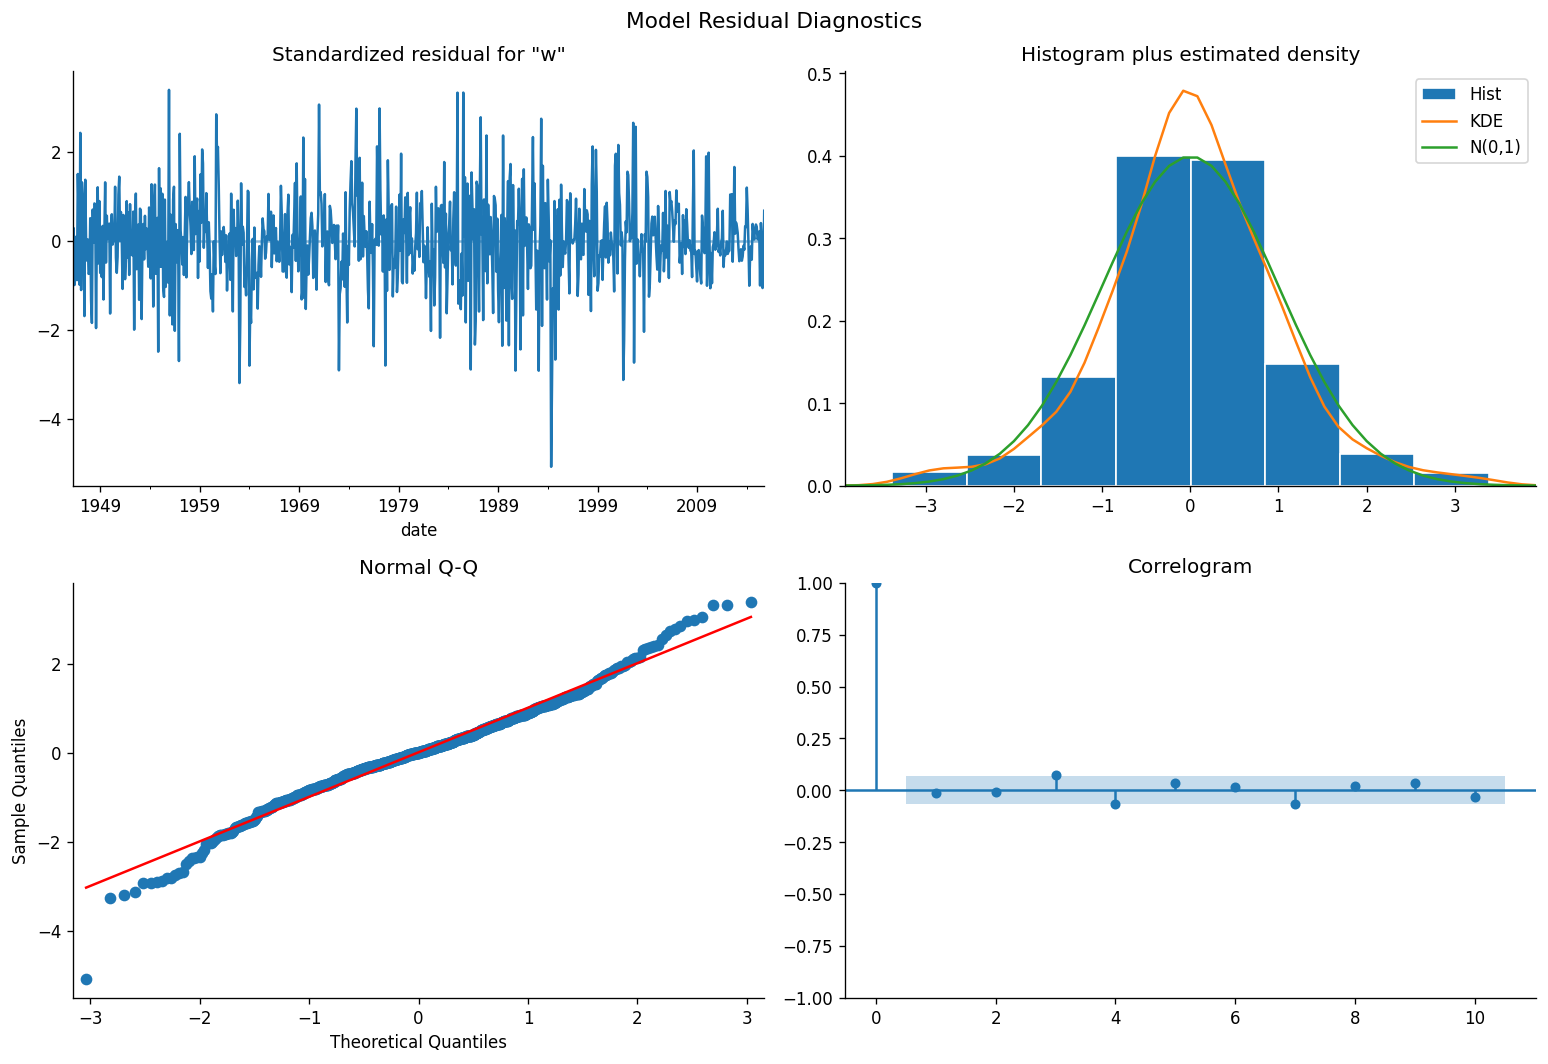

Ljung-Box Test  (p > 0.05 → residuals are white noise — good)
    lb_stat  lb_pvalue
6   11.1835     0.0829
12  21.6279     0.0419
24  54.9867     0.0003


In [ ]:
fig = final_res.plot_diagnostics(figsize=(13, 9))
fig.suptitle('Model Residual Diagnostics', fontsize=13)
plt.tight_layout()
plt.savefig('fig6_diagnostics.png', bbox_inches='tight')
plt.show()

lb = acorr_ljungbox(final_res.resid, lags=[6, 12, 24], return_df=True)
print('Ljung-Box Test  (p > 0.05 → residuals are white noise — good)')
print(lb.round(4).to_string())

## 9. Findings Summary

In [ ]:
print('=' * 65)
print('SARIMAX FINDINGS SUMMARY')
print('=' * 65)
print(f"""
Model           : SARIMAX{best['order']}x{best['seasonal_order']}
Exogenous vars  : {EXOG_COLS}  (raw, no lags)
Exog note       : Contemporaneous met vars used at forecast time
                  (oracle assumption — same setup used for LSTM/TCN)
Training period : {y_trainval.index.min().date()} → {y_trainval.index.max().date()}
Test period     : {y_test.index.min().date()} → {y_test.index.max().date()}

bayesian_optimization:
    n_trials: {len(bayes_results)},
    sampler: Optuna TPE,
    criterion: val_RMSE,
    best_val_RMSE: {round(float(best['val_RMSE']), 4)},
    best_AIC: {round(float(best['AIC']), 4)},


--- Test Set Metrics ---
RMSE      : {global_metrics['RMSE']}
MAE       : {global_metrics['MAE']}
MAPE (%)  : {global_metrics['MAPE (%)']}
R²        : {global_metrics['R²']}
NSE       : {global_metrics['NSE']}

--- Peak Performance (≥ 90th percentile) ---
Peak RMSE : {peak_metrics['Peak RMSE']}
Peak MAE  : {peak_metrics['Peak MAE']}
Avg Bias  : {peak_metrics['Avg bias (Act-Pred)']}

""")
print('=' * 65)

SARIMAX FINDINGS SUMMARY

Model           : SARIMAX(2, 1, 1)x(2, 0, 2, 12)
Exogenous vars  : ['temperature', 'precipitation', 'wind_speed']  (raw, no lags)
Exog note       : Contemporaneous met vars used at forecast time
                  (oracle assumption — same setup used for LSTM/TCN)
Training period : 1944-01-01 → 2015-10-01
Test period     : 2015-11-01 → 2023-10-01

bayesian_optimization:
    n_trials: 50,
    sampler: Optuna TPE,
    criterion: val_RMSE,
    best_val_RMSE: 3.9723,
    best_AIC: 4623.9461,


--- Test Set Metrics ---
RMSE      : 5.154
MAE       : 4.1969
MAPE (%)  : 6.5844
R²        : -0.3826
NSE       : -0.3826

--- Peak Performance (≥ 90th percentile) ---
Peak RMSE : 3.0496
Peak MAE  : 2.8794
Avg Bias  : 2.8794




# Hugging face

In [ ]:
import os
import json
import shutil
import joblib
from pathlib import Path
from huggingface_hub import HfApi, create_repo

In [ ]:
from google.colab import userdata
HF_USERNAME = 'kozy9'       # your HF username
REPO_NAME   = 'GWSarimax'      # whatever you want the repo called
HF_TOKEN    = userdata.get('Huggingface')    # your write token

In [ ]:

REPO_ID   = f'{HF_USERNAME}/{REPO_NAME}'
LOCAL_DIR = Path('hf_upload')
LOCAL_DIR.mkdir(exist_ok=True)

print(f'Preparing upload to: https://huggingface.co/{REPO_ID}')

Preparing upload to: https://huggingface.co/kozy9/GWSarimax


In [ ]:
model_path = LOCAL_DIR / 'sarimax_model.pkl'
joblib.dump(final_res, model_path)
print(f'Model saved  →  {model_path}  ({model_path.stat().st_size / 1024:.1f} KB)')

Model saved  →  hf_upload/sarimax_model.pkl  (119067.8 KB)


In [ ]:
# ── 2. Save model config & metrics ────────────────────────────────────────────
config = {
    'model_type'      : 'SARIMAX',
    'order'           : list(best['order']),
    'seasonal_order'  : list(best['seasonal_order']),
    'seasonal_period' : SEASONAL_PERIOD,
    'target'          : TARGET,
    'exog_cols'       : EXOG_COLS,
    'enforce_stationarity' : False,
    'enforce_invertibility': False,
    'train_period': {
        'start': str(y_trainval.index.min().date()),
        'end'  : str(y_trainval.index.max().date()),
        'n_obs': len(y_trainval),
    },
    'test_period': {
        'start': str(y_test.index.min().date()),
        'end'  : str(y_test.index.max().date()),
        'n_obs': len(y_test),
    },
    'test_metrics': {
        'RMSE'    : round(float(global_metrics['RMSE']),     4),
        'MAE'     : round(float(global_metrics['MAE']),      4),
        'MAPE_pct': round(float(global_metrics['MAPE (%)']), 4),
        'R2'      : round(float(global_metrics['R²']),       4),
        'NSE'     : round(float(global_metrics['NSE']),      4),
    },
    'bayesian_optimization': {
        'n_trials': len(bayes_results),
        'sampler': 'Optuna TPE',
        'criterion': 'val_RMSE',
        'best_val_RMSE': round(float(best['val_RMSE']), 4),
        'best_AIC': round(float(best['AIC']), 4),
    },
    'notes': 'Basic SARIMAX — raw exog only, no lag features. Oracle exog assumption at forecast time.'
}

config_path = LOCAL_DIR / 'model_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)

print(f'Config saved →  {config_path}')
print(json.dumps(config, indent=2))

Config saved →  hf_upload/model_config.json
{
  "model_type": "SARIMAX",
  "order": [
    2,
    1,
    1
  ],
  "seasonal_order": [
    2,
    0,
    2,
    12
  ],
  "seasonal_period": 12,
  "target": "water_level",
  "exog_cols": [
    "temperature",
    "precipitation",
    "wind_speed"
  ],
  "enforce_stationarity": false,
  "enforce_invertibility": false,
  "train_period": {
    "start": "1944-01-01",
    "end": "2015-10-01",
    "n_obs": 862
  },
  "test_period": {
    "start": "2015-11-01",
    "end": "2023-10-01",
    "n_obs": 96
  },
  "test_metrics": {
    "RMSE": 5.154,
    "MAE": 4.1969,
    "MAPE_pct": 6.5844,
    "R2": -0.3826,
    "NSE": -0.3826
  },
  "bayesian_optimization": {
    "n_trials": 50,
    "sampler": "Optuna TPE",
    "criterion": "val_RMSE",
    "best_val_RMSE": 3.9723,
    "best_AIC": 4623.9461
  },
  "notes": "Basic SARIMAX \u2014 raw exog only, no lag features. Oracle exog assumption at forecast time."
}


In [ ]:
# ── 3. Write inference.py ─────────────────────────────────────────────────────
inference_code = '''
"""
inference.py — SARIMAX Groundwater Level Forecasting
=====================================================
Usage
-----
    from inference import load_model, forecast
    model = load_model()
    predictions, conf_int = forecast(model, steps=12, exog_future=X_future)
"""

import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

MODEL_PATH  = Path(__file__).parent / "sarimax_model.pkl"
CONFIG_PATH = Path(__file__).parent / "model_config.json"


def load_model():
    """Load the fitted SARIMAX model."""
    return joblib.load(MODEL_PATH)


def load_config():
    """Load model configuration and metrics."""
    with open(CONFIG_PATH) as f:
        return json.load(f)


def forecast(model, steps: int, exog_future: pd.DataFrame):
    """
    Generate a forecast.

    Parameters
    ----------
    model       : fitted SARIMAX result (from load_model)
    steps       : number of months ahead to forecast
    exog_future : DataFrame with columns [temperature, precipitation, wind_speed]
                  Must have a DatetimeIndex with freq=\'MS\' and exactly `steps` rows.

    Returns
    -------
    predictions : pd.Series  — point forecasts
    conf_int    : pd.DataFrame — 95% confidence interval
    """
    cfg           = load_config()
    required_cols = cfg[\'exog_cols\']

    missing = [c for c in required_cols if c not in exog_future.columns]
    if missing:
        raise ValueError(f"exog_future is missing columns: {missing}")
    if len(exog_future) != steps:
        raise ValueError(f"exog_future must have {steps} rows, got {len(exog_future)}")

    fc          = model.get_forecast(steps=steps, exog=exog_future[required_cols])
    predictions = fc.predicted_mean
    conf_int    = fc.conf_int()
    return predictions, conf_int


if __name__ == "__main__":
    model = load_model()
    cfg   = load_config()
    print(f"Model loaded: SARIMAX{cfg[\'order\']}x{cfg[\'seasonal_order\']}")
    print(f"Test RMSE: {cfg[\'test_metrics\'][\'RMSE\']}")

    # Dummy forecast — replace with real future met data
    idx   = pd.date_range(start="2024-01-01", periods=12, freq="MS")
    X_fut = pd.DataFrame({
        "temperature"  : np.random.uniform(3, 15, 12),
        "precipitation": np.random.uniform(20, 120, 12),
        "wind_speed"   : np.random.uniform(10, 25, 12),
    }, index=idx)

    preds, ci = forecast(model, steps=12, exog_future=X_fut)
    print(pd.DataFrame({"predicted": preds, "lower": ci.iloc[:,0], "upper": ci.iloc[:,1]}))
'''

inference_path = LOCAL_DIR / 'inference.py'
inference_path.write_text(inference_code.strip())
print(f'Inference script saved →  {inference_path}')

Inference script saved →  hf_upload/inference.py


In [ ]:
# ── 4. Write README / model card ──────────────────────────────────────────────
m  = config['test_metrics']
o  = config['order']
so = config['seasonal_order']

readme = f"""---
license: mit
tags:
  - time-series
  - forecasting
  - sarimax
  - hydrology
  - groundwater
---

# SARIMAX Groundwater Level Forecasting — UK

A SARIMAX model trained to forecast monthly groundwater levels (GWLs)
using historical water level data and meteorological variables.

## Model Details

| Parameter | Value |
|---|---|
| Architecture | SARIMAX{tuple(o)}x{tuple(so)} |
| Seasonal period | {SEASONAL_PERIOD} months |
| Target | Water level (m) |
| Exogenous variables | Temperature (°C), Precipitation (mm), Wind Speed (km/h) |
| Feature engineering | None — raw exog only |
| Training period | {config['train_period']['start']} → {config['train_period']['end']} ({config['train_period']['n_obs']} months) |
| Test period | {config['test_period']['start']} → {config['test_period']['end']} ({config['test_period']['n_obs']} months) |

## Hyperparameter Tuning

Bayesian search : {len(bayes_results)} trials | criterion: validation RMSE
ranked by out-of-sample validation RMSE.



## Test Set Performance

| Metric | Value |
|---|---|
| RMSE | {m['RMSE']} |
| MAE | {m['MAE']} |
| MAPE (%) | {m['MAPE_pct']} |
| R² | {m['R2']} |
| NSE | {m['NSE']} |

> This model is a statistical baseline for benchmarking against
> deep learning approaches (LSTM, TCN).

## Important Note

Contemporaneous meteorological variables are used as exogenous inputs
at forecast time (oracle assumption). Future met values are treated as known.
This matches the experimental setup used for LSTM/TCN comparisons in this study.

## Repository Contents

```
├── sarimax_model.pkl     # Fitted model (joblib)
├── model_config.json     # Parameters, metadata & metrics
├── inference.py          # Load model & generate forecasts
└── README.md             # This file
```

## Quick Start

```python
from huggingface_hub import hf_hub_download
import joblib, pandas as pd, numpy as np

model_path = hf_hub_download(repo_id='{REPO_ID}', filename='sarimax_model.pkl')
model = joblib.load(model_path)

idx   = pd.date_range(start='2024-01-01', periods=12, freq='MS')
X_fut = pd.DataFrame({{
    'temperature'  : [...],
    'precipitation': [...],
    'wind_speed'   : [...],
}}, index=idx)

fc   = model.get_forecast(steps=12, exog=X_fut)
pred = fc.predicted_mean
ci   = fc.conf_int()
```
"""

readme_path = LOCAL_DIR / 'README.md'
readme_path.write_text(readme)
print(f'Model card saved  →  {readme_path}')

Model card saved  →  hf_upload/README.md


In [ ]:
# ── 5. Copy any saved figures ─────────────────────────────────────────────────
for fig_file in Path('.').glob('fig*.png'):
    shutil.copy(fig_file, LOCAL_DIR / fig_file.name)
    print(f'Copied {fig_file.name}')

print('\nFiles ready for upload:')
for f in sorted(LOCAL_DIR.iterdir()):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.1f} KB)')

Copied fig4_forecast.png
Copied fig3_acf_pacf.png
Copied fig5_error_analysis.png
Copied fig1_overview.png
Copied fig6_diagnostics.png
Copied fig2_decomposition.png

Files ready for upload:
  README.md  (2.1 KB)
  fig1_overview.png  (532.8 KB)
  fig2_decomposition.png  (343.7 KB)
  fig3_acf_pacf.png  (37.5 KB)
  fig4_forecast.png  (131.0 KB)
  fig5_error_analysis.png  (47.5 KB)
  fig6_diagnostics.png  (164.3 KB)
  inference.py  (2.4 KB)
  model_config.json  (0.9 KB)
  sarimax_model.pkl  (119067.8 KB)


In [ ]:
# ── 6. Create repo & upload everything ───────────────────────────────────────
api = HfApi()

create_repo(
    repo_id   = REPO_ID,
    token     = HF_TOKEN,
    repo_type = 'model',
    exist_ok  = True,
    private   = False,
)
print(f'Repo ready: https://huggingface.co/{REPO_ID}')

api.upload_folder(
    folder_path    = str(LOCAL_DIR),
    repo_id        = REPO_ID,
    repo_type      = 'model',
    token          = HF_TOKEN,
    commit_message = f'Upload SARIMAX{best["order"]}x{best["seasonal_order"]} — test RMSE {global_metrics["RMSE"]:.4f}',
)

print(f'\nUpload complete!')
print(f'View at: https://huggingface.co/{REPO_ID}')

Repo ready: https://huggingface.co/kozy9/GWSarimax



Upload complete!
View at: https://huggingface.co/kozy9/GWSarimax


# Gradio Trying

In [ ]:
import numpy as np
import pandas as pd
import joblib
import json
import gradio as gr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load model & config locally
model = joblib.load("hf_upload/sarimax_model.pkl")
with open("hf_upload/model_config.json") as f:
    config = json.load(f)

EXOG_COLS = config["exog_cols"]


# ── Forecast function ─────────────────────────────────────────────────────────
def forecast(steps, start_date, temperatures, precipitations, wind_speeds):
    """
    Takes user inputs, runs SARIMAX forecast, returns a plot and metrics table.
    """
    try:
        # Parse inputs (comma-separated strings → lists)
        temps  = [float(x.strip()) for x in temperatures.split(",")]
        precip = [float(x.strip()) for x in precipitations.split(",")]
        winds  = [float(x.strip()) for x in wind_speeds.split(",")]

        # Validate lengths
        if not (len(temps) == len(precip) == len(winds) == steps):
            return None, f"Please provide exactly {steps} comma-separated values for each meteorological variable."

        # Build exog DataFrame
        idx   = pd.date_range(start=start_date, periods=steps, freq="MS")
        X_fut = pd.DataFrame({
            "temperature"  : temps,
            "precipitation": precip,
            "wind_speed"   : winds,
        }, index=idx)

        # Run forecast
        fc          = model.get_forecast(steps=steps, exog=X_fut[EXOG_COLS])
        predictions = fc.predicted_mean
        ci          = fc.conf_int()

        # ── Plot ──────────────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(12, 5))

        ax.plot(predictions.index, predictions,
                color="crimson", lw=2, linestyle="--", marker="o",
                markersize=4, label="Forecast")
        ax.fill_between(
            ci.index, ci.iloc[:, 0], ci.iloc[:, 1],
            color="crimson", alpha=0.15, label="95% CI"
        )

        ax.set_title(
            f"SARIMAX{tuple(config['order'])}x{tuple(config['seasonal_order'])} — "
            f"Groundwater Level Forecast ({steps} months)",
            fontsize=13
        )
        ax.set_xlabel("Date")
        ax.set_ylabel("Water Level (m)")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=max(1, steps // 8)))
        plt.xticks(rotation=45)
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        plt.tight_layout()

        # ── Results table ─────────────────────────────────────────────────────
        results_df = pd.DataFrame({
            "Date"           : predictions.index.strftime("%Y-%m"),
            "Forecast (m)"   : predictions.round(4).values,
            "Lower 95% CI"   : ci.iloc[:, 0].round(4).values,
            "Upper 95% CI"   : ci.iloc[:, 1].round(4).values,
        })

        return fig, results_df, ""

    except Exception as e:
        return None, None, f"Error: {str(e)}"


# ── Helper: auto-fill example values ─────────────────────────────────────────
def fill_example(steps):
    temps  = ", ".join(["8.5"]  * steps)
    precip = ", ".join(["65.0"] * steps)
    winds  = ", ".join(["15.0"] * steps)
    return temps, precip, winds


# ── Gradio UI ─────────────────────────────────────────────────────────────────
with gr.Blocks(title="SARIMAX Groundwater Forecaster") as demo:

    gr.Markdown(
        f"""
        # SARIMAX Groundwater Level Forecaster — UK
        Forecast monthly groundwater levels using meteorological inputs.

        **Model:** `SARIMAX{tuple(config['order'])}x{tuple(config['seasonal_order'])}`
        **Test RMSE:** {config['test_metrics']['RMSE']} m &nbsp;|&nbsp;
        **R²:** {config['test_metrics']['R2']} &nbsp;|&nbsp;
        **NSE:** {config['test_metrics']['NSE']}

        > **Note:** This model uses contemporaneous meteorological values as inputs
        > (oracle assumption). Provide your best estimates or observed values for the forecast period.
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            steps      = gr.Slider(minimum=1, maximum=36, value=12, step=1,
                                   label="Forecast horizon (months)")
            start_date = gr.Textbox(value="2024-01-01",
                                    label="Start date (YYYY-MM-DD)")

            gr.Markdown("### Meteorological Inputs")
            gr.Markdown("Enter comma-separated values — one per forecast month.")

            temperatures  = gr.Textbox(label="Temperature (°C)",
                                       placeholder="e.g. 8.5, 9.0, 10.2, ...")
            precipitations = gr.Textbox(label="Precipitation (mm)",
                                        placeholder="e.g. 65.0, 72.3, 50.1, ...")
            wind_speeds    = gr.Textbox(label="Wind Speed (km/h)",
                                        placeholder="e.g. 15.0, 13.5, 17.2, ...")

            with gr.Row():
                fill_btn     = gr.Button("Fill Example Values", variant="secondary")
                forecast_btn = gr.Button("Run Forecast", variant="primary")

            error_box = gr.Textbox(label="", visible=True, interactive=False)

        with gr.Column(scale=2):
            plot_out  = gr.Plot(label="Forecast Plot")
            table_out = gr.Dataframe(label="Forecast Values", wrap=True)

    # ── Wire up buttons ───────────────────────────────────────────────────────
    fill_btn.click(
        fn=fill_example,
        inputs=[steps],
        outputs=[temperatures, precipitations, wind_speeds],
    )

    forecast_btn.click(
        fn=forecast,
        inputs=[steps, start_date, temperatures, precipitations, wind_speeds],
        outputs=[plot_out, table_out, error_box],
    )

    gr.Markdown(
        """
        ---
        **Exogenous variables:** Temperature (°C), Precipitation (mm), Wind Speed (km/h)
        **Seasonal period:** 12 months
        **Training data:** 1944 – 2015
        """
    )

demo.launch(share=False, inbrowser=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>